In [1]:
!unzip statlog+german+credit+data.zip

Archive:  statlog+german+credit+data.zip
  inflating: german.data             
  inflating: german.data-numeric     
  inflating: german.doc              
  inflating: Index                   


In [1]:
# Import Required Libraries
import os
import warnings
warnings.filterwarnings("ignore")

# Core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings for better readability
plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

### Load the Dataset

In [2]:
# Path to the dataset file
file_path = "german.data"

In [3]:
# Column names as provided in dataset documentation
column_names = [
    "Status_Checking_Account",
    "Duration_Months",
    "Credit_History",
    "Purpose",
    "Credit_Amount",
    "Savings_Account",
    "Employment_Since",
    "Installment_Rate",
    "Personal_Status_Sex",
    "Other_Debtors",
    "Residence_Since",
    "Property",
    "Age",
    "Other_Installment_Plans",
    "Housing",
    "Existing_Credits",
    "Job",
    "Num_Dependents",
    "Telephone",
    "Foreign_Worker",
    "Target"
]

In [4]:
# Dataset is space-separated and has no header
df = pd.read_csv(file_path, sep=" ", header=None)
df.columns = column_names

### Initial Data Inspection

In [5]:
# Dataset preview
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,Status_Checking_Account,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Num_Dependents,Telephone,Foreign_Worker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
# Dataset preview
print("\nLast 5 Rows:")
df.tail()


Last 5 Rows:


,Status_Checking_Account,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Num_Dependents,Telephone,Foreign_Worker,Target
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2
999,A12,45,A34,A41,4576,A62,A71,3,A93,A101,...,A123,27,A143,A152,1,A173,1,A191,A201,1


In [7]:
# Dataset shape
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(1000, 21)


In [8]:
# Dataset types
print("\nData Types:")
print(df.dtypes)


Data Types:
Status_Checking_Account    object
Duration_Months             int64
Credit_History             object
Purpose                    object
Credit_Amount               int64
Savings_Account            object
Employment_Since           object
Installment_Rate            int64
Personal_Status_Sex        object
Other_Debtors              object
Residence_Since             int64
Property                   object
Age                         int64
Other_Installment_Plans    object
Housing                    object
Existing_Credits            int64
Job                        object
Num_Dependents              int64
Telephone                  object
Foreign_Worker             object
Target                      int64
dtype: object


In [9]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Status_Checking_Account    0
Duration_Months            0
Credit_History             0
Purpose                    0
Credit_Amount              0
Savings_Account            0
Employment_Since           0
Installment_Rate           0
Personal_Status_Sex        0
Other_Debtors              0
Residence_Since            0
Property                   0
Age                        0
Other_Installment_Plans    0
Housing                    0
Existing_Credits           0
Job                        0
Num_Dependents             0
Telephone                  0
Foreign_Worker             0
Target                     0
dtype: int64


In [10]:
print("\nTarget Distribution:")
df["Target"].value_counts()


Target Distribution:


,count
Target,
1,700
2,300


In [11]:
# Convert target for easier interpretation
# 1 = Good, 2 = Bad  → Convert to Good(0), Bad(1)
df["Target"] = df["Target"].map({1: 0, 2: 1})

In [12]:
print("Updated Target Distribution (0 = Good, 1 = Bad):")
df["Target"].value_counts()

Updated Target Distribution (0 = Good, 1 = Bad):


,count
Target,
0,700
1,300


In [13]:
# Data Statistical summary
print("\nStatistical Summary (Numerical Features):")
df.describe()


Statistical Summary (Numerical Features):


,Duration_Months,Credit_Amount,Installment_Rate,Residence_Since,Age,Existing_Credits,Num_Dependents,Target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


### Exploratory Data Analysis

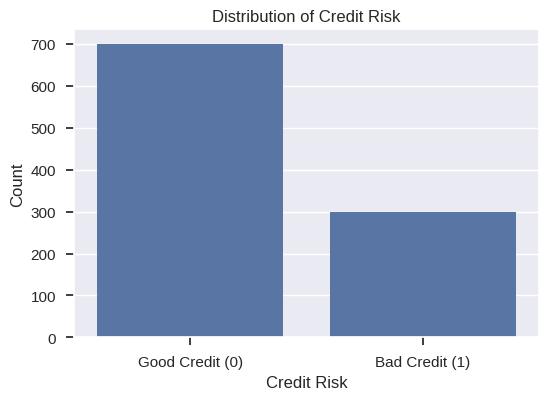

In [14]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df)
plt.title("Distribution of Credit Risk")
plt.xticks([0,1], ["Good Credit (0)", "Bad Credit (1)"])
plt.xlabel("Credit Risk")
plt.ylabel("Count")
plt.show()

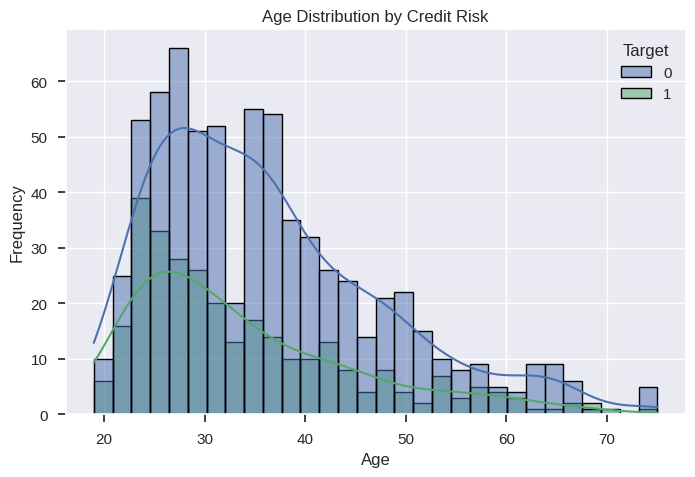

In [15]:
# Age Distribution by Credit Risk
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Target", bins=30, kde=True)
plt.title("Age Distribution by Credit Risk")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

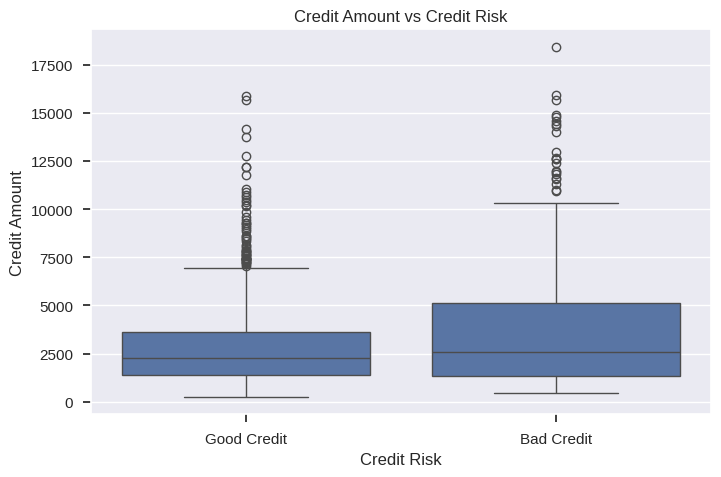

In [16]:
# Credit Amount vs Target
plt.figure(figsize=(8,5))
sns.boxplot(x="Target", y="Credit_Amount", data=df)
plt.title("Credit Amount vs Credit Risk")
plt.xticks([0,1], ["Good Credit", "Bad Credit"])
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")
plt.show()

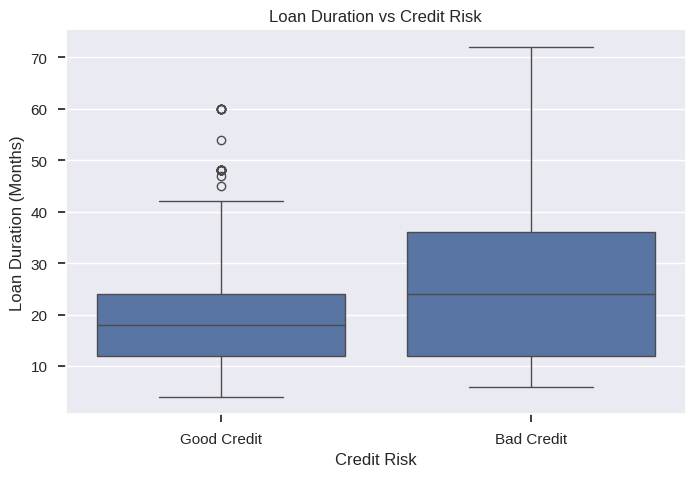

In [17]:
# Loan Duration vs Target
plt.figure(figsize=(8,5))
sns.boxplot(x="Target", y="Duration_Months", data=df)
plt.title("Loan Duration vs Credit Risk")
plt.xticks([0,1], ["Good Credit", "Bad Credit"])
plt.xlabel("Credit Risk")
plt.ylabel("Loan Duration (Months)")
plt.show()

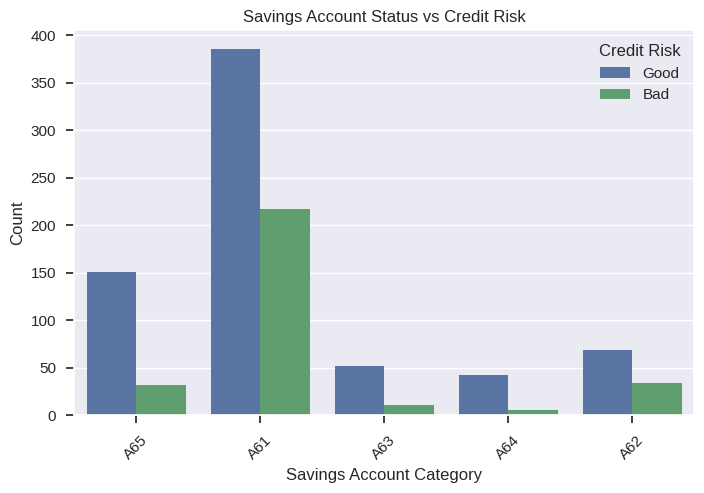

In [18]:
# Savings Account Status vs Target
plt.figure(figsize=(8,5))
sns.countplot(x="Savings_Account", hue="Target", data=df)
plt.title("Savings Account Status vs Credit Risk")
plt.xlabel("Savings Account Category")
plt.ylabel("Count")
plt.legend(title="Credit Risk", labels=["Good", "Bad"])
plt.xticks(rotation=45)
plt.show()

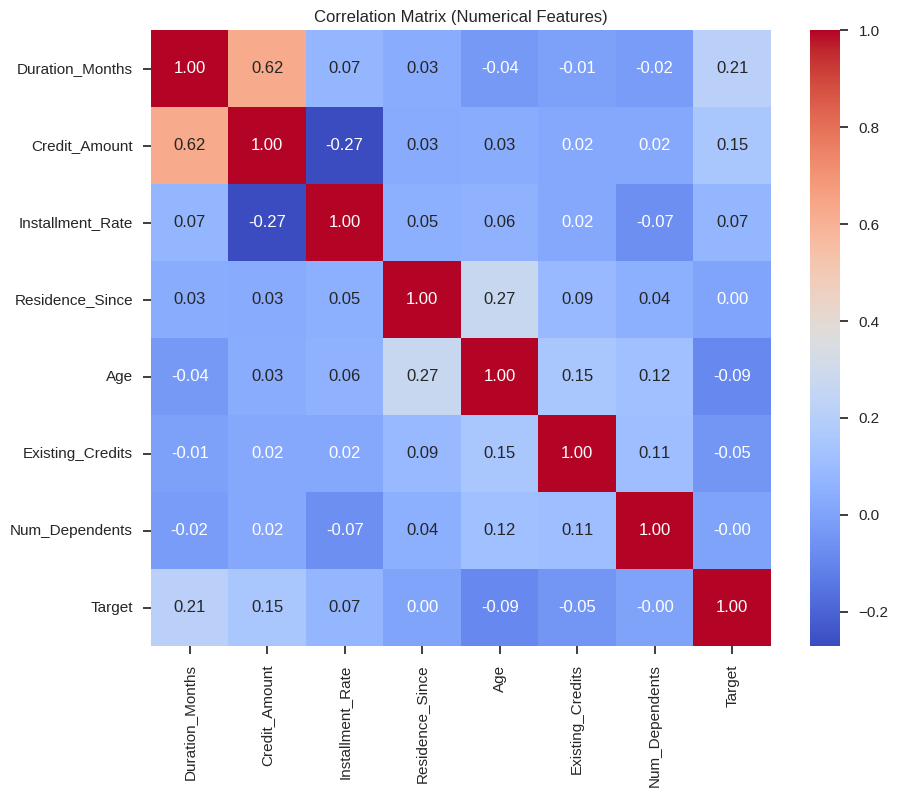

In [19]:
# Correlation Heatmap
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

### PREPROCESSING AND FEATURE ENGINEERING

In [20]:
# Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score

In [21]:
# Separate features and target
X = df.drop("Target", axis=1)
y = df["Target"]

In [22]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64"]).columns

print("Categorical Features:", categorical_cols)
print("\nNumerical Features:", numerical_cols)

Categorical Features: Index(['Status_Checking_Account', 'Credit_History', 'Purpose',
       'Savings_Account', 'Employment_Since', 'Personal_Status_Sex',
       'Other_Debtors', 'Property', 'Other_Installment_Plans', 'Housing',
       'Job', 'Telephone', 'Foreign_Worker'],
      dtype='object')

Numerical Features: Index(['Duration_Months', 'Credit_Amount', 'Installment_Rate',
       'Residence_Since', 'Age', 'Existing_Credits', 'Num_Dependents'],
      dtype='object')


In [23]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

In [24]:
# Train-Test Split (80-20) using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (800, 20)
Testing set size: (200, 20)


### MODEL BUILDING AND EVALUATION

In [25]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

* Logistic Regression model

In [26]:
# Logistic Regression
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))])

In [27]:
# Train logistic model
log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Duration_Months', 'Credit_Amount', 'Installment_Rate',
       'Residence_Since', 'Age', 'Existing_Credits', 'Num_Dependents'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Status_Checking_Account', 'Credit_History', 'Purpose',
       'Savings_Account', 'Employment_Since', 'Personal_Status_Sex',
       'Other_Debtors', 'Property', 'Other_Installment_Plans', 'Housing',
       'Job', 'Telephone', 'Foreign_Worker'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [28]:
# Make prediction and test model
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [29]:
# Classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80       140
           1       0.55      0.78      0.64        60

    accuracy                           0.74       200
   macro avg       0.72      0.75      0.72       200
weighted avg       0.78      0.74      0.75       200



* Random Forest Model

In [30]:
# Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [31]:
# Train random forest model
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Duration_Months', 'Credit_Amount', 'Installment_Rate',
       'Residence_Since', 'Age', 'Existing_Credits', 'Num_Dependents'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Status_Checking_Account', 'Credit_History', 'Purpose',
       'Savings_Account', 'Employment_Since', 'Personal_Status_Sex',
       'Other_Debtors', 'Property', 'Other_Installment_Plans', 'Housing',
       'Job', 'Telephone', 'Foreign_Worker'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [32]:
# Make prediction and test model
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [33]:
# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       140
           1       0.70      0.38      0.49        60

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.67       200
weighted avg       0.75      0.77      0.74       200



* Gradient Boosting Model

In [34]:
# Gradient Boosting
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

In [35]:
# Train gradient boosting model
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Duration_Months', 'Credit_Amount', 'Installment_Rate',
       'Residence_Since', 'Age', 'Existing_Credits', 'Num_Dependents'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Status_Checking_Account', 'Credit_History', 'Purpose',
       'Savings_Account', 'Employment_Since', 'Personal_Status_Sex',
       'Other_Debtors', 'Property', 'Other_Installment_Plans', 'Housing',
       'Job', 'Telephone', 'Foreign_Worker'],
      dtype='object'))])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [36]:
# Make prediction and test model
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [37]:
# Classification report
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       140
           1       0.66      0.55      0.60        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



* Model Comparision

In [38]:
# Function to calculate evaluation metrics
def evaluate_model(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, y_pred_log),
    "Random Forest": evaluate_model(y_test, y_pred_rf),
    "Gradient Boosting": evaluate_model(y_test, y_pred_gb)
})

print("Model Comparison:")
results.T

Model Comparison:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.740,0.546512,0.783333,0.643836
Random Forest,0.765,0.696970,0.383333,0.494624
Gradient Boosting,0.780,0.660000,0.550000,0.600000


#### CONFUSION MATRICES

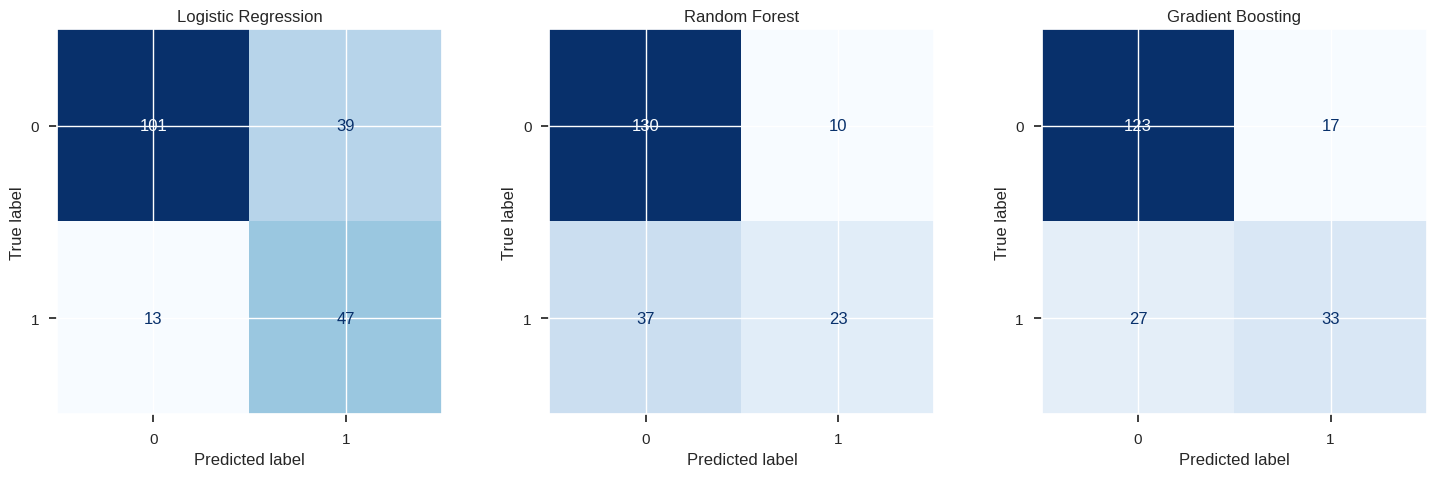

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    "Logistic Regression": (y_pred_log, axes[0]),
    "Random Forest": (y_pred_rf, axes[1]),
    "Gradient Boosting": (y_pred_gb, axes[2])
}

for name, (pred, ax) in models.items():
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.show()

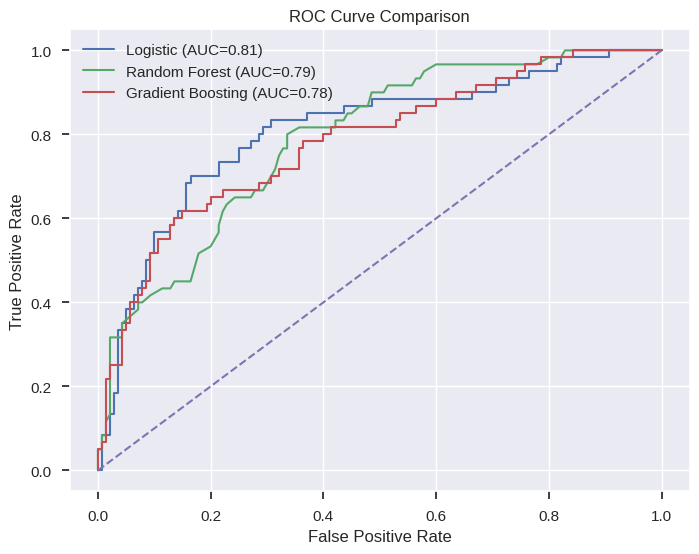

In [40]:
# ROC CURVE COMPARISON
plt.figure(figsize=(8,6))

# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={roc_auc_score(y_test,y_prob_log):.2f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test,y_prob_rf):.2f})")

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={roc_auc_score(y_test,y_prob_gb):.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

* EXPLAINABLE ANALYSIS

In [41]:
# Install and Import (SHAP)
!pip -q install shap

import shap

In [42]:
# Fit preprocessor separately
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [43]:
# Get numerical feature names
num_features = numerical_cols

# Get encoded categorical feature names
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

# Combine all feature names
all_feature_names = np.concatenate([num_features, cat_features])

In [44]:
X_test_transformed_df = pd.DataFrame(X_test_transformed,columns=all_feature_names)

In [45]:
# Extract trained Random Forest model
rf_trained = rf_model.named_steps["classifier"]

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_trained)

shap_values = explainer.shap_values(X_test_transformed_df)

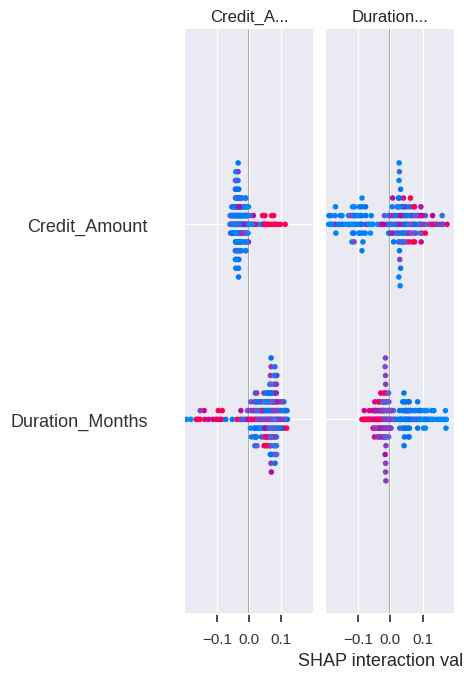

In [46]:
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_transformed_df)
else:
    shap.summary_plot(shap_values, X_test_transformed_df)

* EXPLAINABLE AI – LIME

In [47]:
# Install LIME
!pip -q install lime

from lime.lime_tabular import LimeTabularExplainer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


* Prepare Data for LIME

In [48]:
# Extract trained Random Forest model
rf_trained = rf_model.named_steps["classifier"]

# Use the already fitted preprocessor
preprocessor.fit(X_train)

# Transform training and testing data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after encoding
num_features = numerical_cols
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([num_features, cat_features])

In [49]:
# Create LIME explainer using transformed training data
lime_explainer = LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=all_feature_names,
    class_names=["Good Credit", "Bad Credit"],
    mode="classification",
    discretize_continuous=True
)

In [51]:
# Selecting one instance to explain
i = 0

# Generate explanation
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_transformed[i],
    predict_fn=rf_trained.predict_proba,
    num_features=10  # Top 10 contributing features
)

# Show explanation
lime_exp.show_in_notebook(show_table=True)

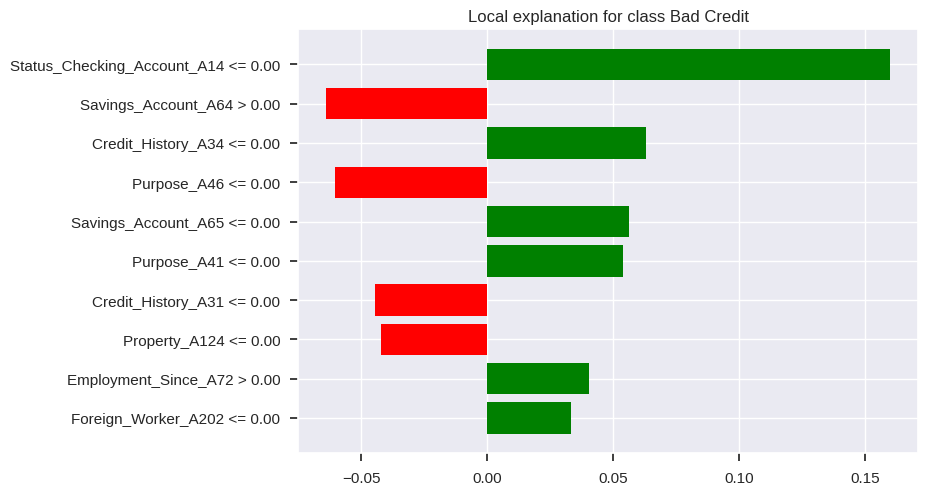

In [52]:
# Plot explanation
fig = lime_exp.as_pyplot_figure()
plt.show()